# Laboratorio 1

In [151]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import unicodedata
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



## Carga de los datos

In [152]:
datos = pd.read_csv('data/Datos Lab 1.csv')
datos_test = pd.read_csv('data/Datos Test Lab 1.csv')

In [153]:
dict = pd.read_excel('./data/Diccionario de datos.xlsx')
pd.set_option('display.max_colwidth', None)
dict

,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día (mbar).
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


### Analisis

Antes de empezar a eliminar variables y hacer el analisis de cuales son las que mas aportan en nuestro modelo y cuales generan redundancia, tenemos que mirar que tan buena calidad de datos tenemos

Revisemos primero el estado de completitud de nuestro dataset:

(2576, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   object 
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   float64
 16  rafaga_desv  

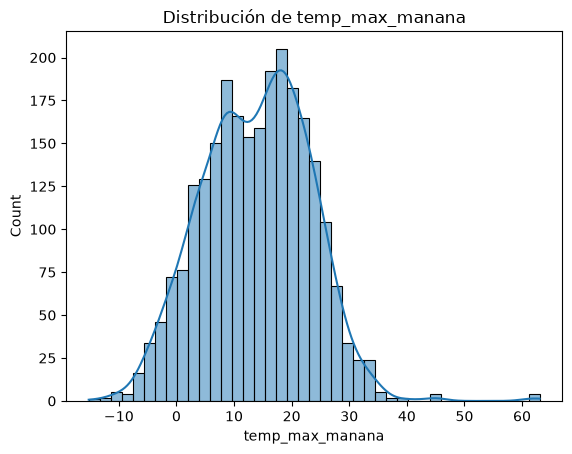

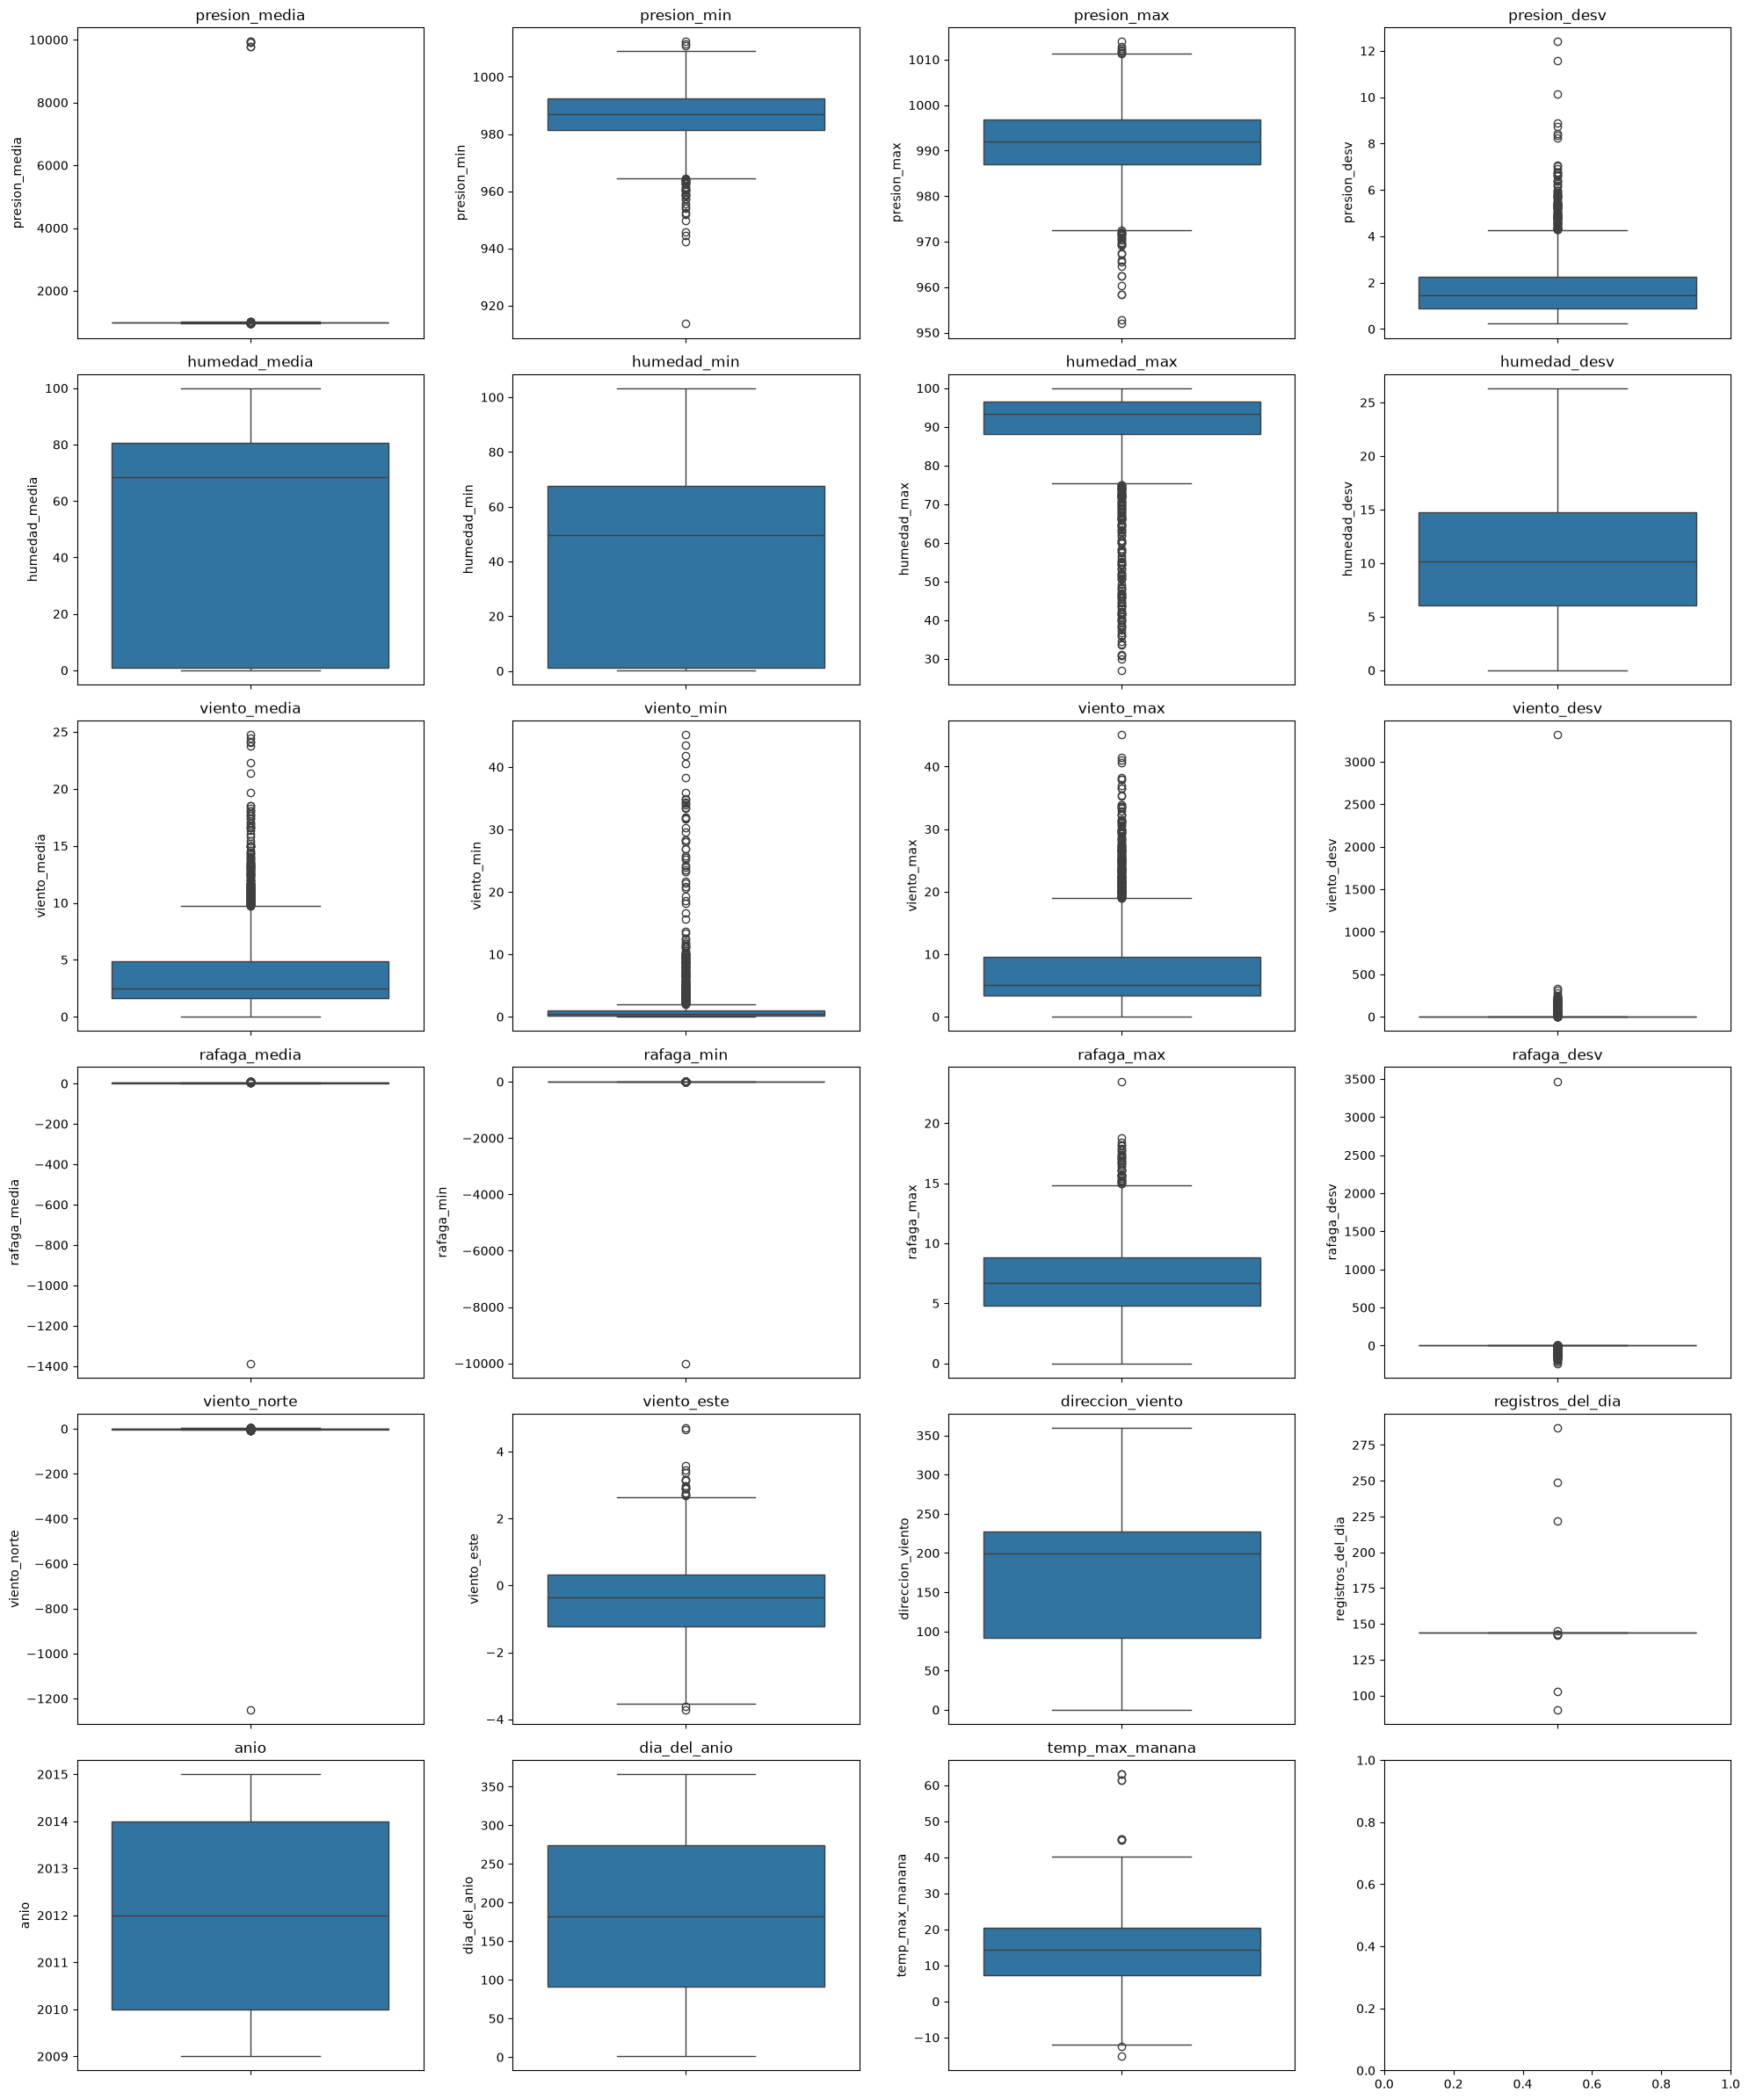

In [154]:
# Carga de datos
df = datos.copy()
df_test = datos_test.copy()

print(df.shape)
df.head()
df.info()
df.describe(include="all")

# Nulos
nulos = df.isnull().sum().sort_values(ascending=False)
nulos_pct = (nulos / len(df) * 100).round(2)
pd.DataFrame({"n_nulos": nulos, "%_nulos": nulos_pct})

# Duplicados
print("Filas duplicadas:", df.duplicated().sum())
print("Fechas duplicadas:", df['fecha'].duplicated().sum())

# Consistencia de rangos (ejemplos)
print((df['presion_min'] > df['presion_media']).sum(), "casos donde min > media (presión)")
print((df['presion_media'] > df['presion_max']).sum(), "casos donde media > max (presión)")
print(((df['humedad_media'] < 0) | (df['humedad_media'] > 100)).sum(), "humedad fuera de rango")
print((df['registros_del_dia'] > 144).sum(), "días con más de 144 registros")

# Distribución de la variable objetivo
sns.histplot(df['temp_max_manana'], kde=True)
plt.title("Distribución de temp_max_manana")
plt.show()

# Boxplots para detectar outliers en variables numéricas
num_cols = df.select_dtypes(include=np.number).columns.tolist()
fig, axes = plt.subplots(len(num_cols)//4 + 1, 4, figsize=(20, 4*(len(num_cols)//4 + 1)))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Con estas graficas ya podemos empezar a ver como se distribuyen nuestas variables, que tanta complititud tenemos en cuantos a variables. Tambien mirando la descripcion de nuestras variables vemos que podemos eliminar algunas que seguramente no valga la pena darle un limpieza y transformacion. pero hay algunas de estas variables que apesar de que no nos ayudan con el analisis y el modelo, nos ayudan para mirar temas de unicidad y otras cosas.
| Variable                            | Razón                                                                                                                                                                                        |
| ----------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `fecha`                             | Identificador tipo texto, ya descompuesto en `anio`, `dia_del_anio`, `mes`, `estacion_anio`. No aporta como predictor.                                                                       |
| `anio`                              | No tiene relación física con la temperatura; es proxy de tendencia climática y puede causar extrapolación errónea si el test tiene años distintos.                                           |
| `direccion_viento`, `sector_viento` | Misma información física que `viento_norte`/`viento_este`, solo en otro formato (grados / categoría). Redundancia evidente por definición.                                                   |
| `mes`, `estacion_anio`              | Son agregaciones de `dia_del_anio`. Se conserva solo `dia_del_anio`, transformado cíclicamente (`seno`/`coseno`) para capturar la estacionalidad sin discontinuidad entre diciembre y enero. |
| `registros_del_dia`                 | Es metadata de calidad de medición, no una variable meteorológica. Se usa para filtrar días con pocos registros (<100) y luego se descarta.                                                  |


In [155]:
# 1. Eliminación de duplicados
print("Duplicados por 'fecha':", df['fecha'].duplicated().sum())
df = df.drop_duplicates(subset=['fecha'], keep='first')

print("Duplicados por 'anio' + 'dia_del_anio':", df.duplicated(subset=['anio', 'dia_del_anio']).sum())
df = df.drop_duplicates(subset=['anio', 'dia_del_anio'], keep='first')

df = df.reset_index(drop=True)

# 2. Eliminación de columnas irrelevantes/redundantes
cols_eliminar = [
    "fecha", "anio", "direccion_viento", "sector_viento","registros_del_dia"
]
df = df.drop(columns=cols_eliminar)

# 3. Completitud
nulos = df.isnull().sum().sort_values(ascending=False)
nulos_pct = (nulos / len(df) * 100).round(2)
tabla_nulos = pd.DataFrame({"n_nulos": nulos, "%_nulos": nulos_pct})
print(tabla_nulos[tabla_nulos["n_nulos"] > 0])

Duplicados por 'fecha': 89
Duplicados por 'anio' + 'dia_del_anio': 62
                 n_nulos  %_nulos
temp_max_manana       89     3.67
viento_min            86     3.55
estacion_anio         86     3.55
mes                   85     3.51
humedad_max           79     3.26
viento_media          79     3.26
presion_desv          77     3.18
rafaga_desv           76     3.13
rafaga_media          76     3.13
viento_max            75     3.09
presion_media         73     3.01
viento_norte          72     2.97
humedad_media         72     2.97
presion_min           71     2.93
humedad_min           71     2.93
viento_desv           69     2.85
rafaga_min            67     2.76
rafaga_max            66     2.72
presion_max           61     2.52
humedad_desv          58     2.39
viento_este           58     2.39
dia_del_anio           8     0.33


---

### Una vez hicimos este ajuste de unicidad, vamos a empezar a mirar las relaciones que tienen nuestras varialbes con la variable objetivo, y asi mismo empezaremos a mirar las realciones entre si de las variables, ya que esto es importante tenerlo en cuenta para nuestro modelo

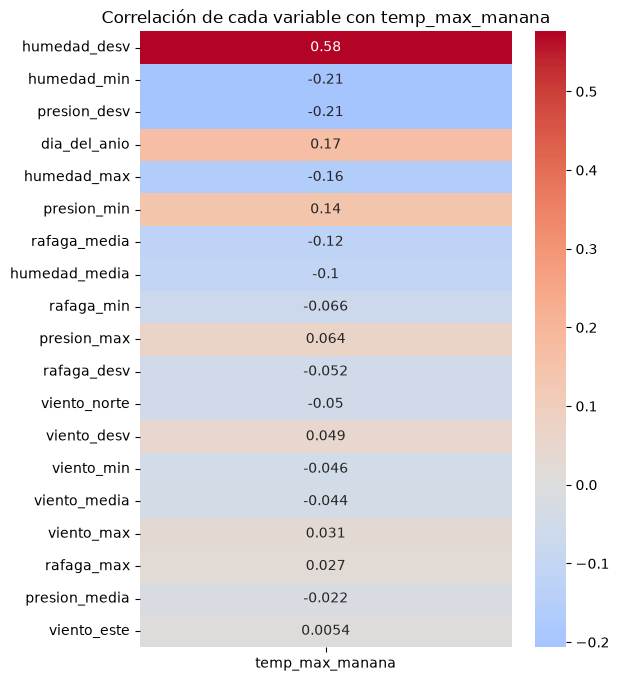

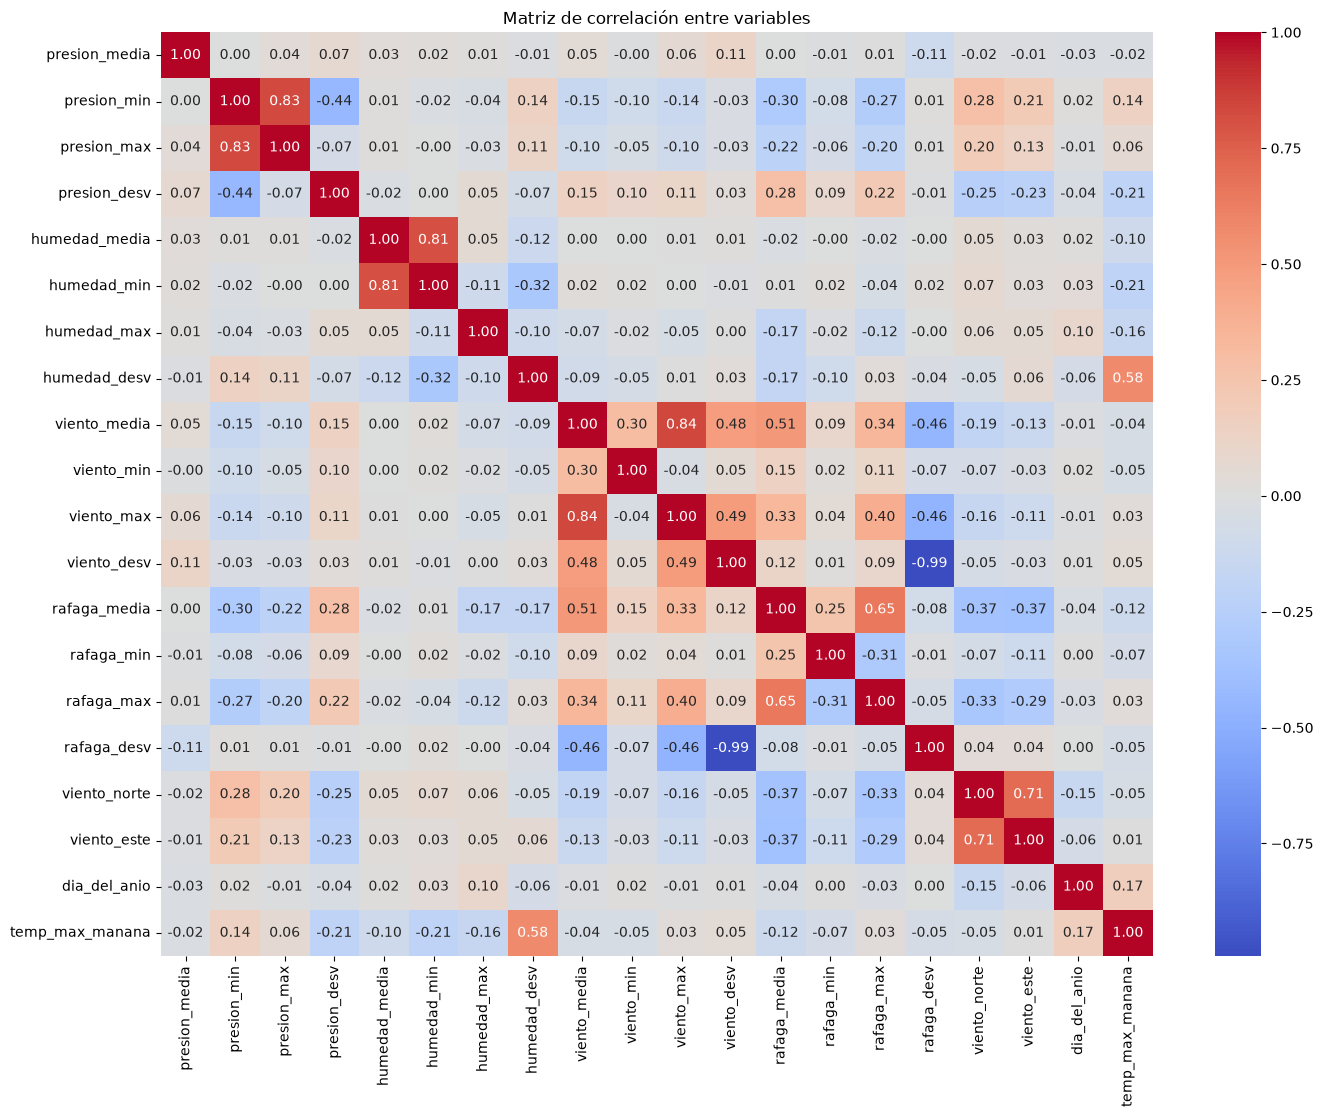

In [156]:
# Correlación de cada variable numérica con el objetivo
target = "temp_max_manana"
num_cols = df.select_dtypes(include=np.number).columns.tolist()

corr_target = df[num_cols].corr()[target].drop(target).sort_values(key=abs, ascending=False)
plt.figure(figsize=(6, 8))
sns.heatmap(corr_target.to_frame(), annot=True, cmap="coolwarm", center=0)
plt.title(f"Correlación de cada variable con {target}")
plt.show()

# Matriz de correlación entre todas las variables (colinealidad)
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f",cmap="coolwarm", center=0)
plt.title("Matriz de correlación entre variables")
plt.show()

Aqui vemos que la mayoria de variables no estan relacionadas con respecto a el target, pero en este momento no hemos eliminado los outliners, ni eliminado los registros que no poseen un valor de target, tambien, hay variables que bajo nuestra consideracion, no tienen mucha relevancia en nuestro modelo, y son los minimos y maximos obervados en cada uno de los registro, ya que estos datos no son datos metereologicos que describan algo fisico, y tambien poseen mucha correlacion entre si mismos, entonces esto tambien puede llegar a afectar nuestro modelo, en cuanto a las variable `viento_norte` y `viento_este`, apesar de que poseen una correlacion importante, estas describen factores diferentes.

presion_media: 3 outliers fuera de [192.02, 1809.77]
presion_min: 36 outliers fuera de [964.41, 1008.90]
presion_max: 31 outliers fuera de [972.47, 1010.83]
presion_desv: 66 outliers fuera de [-1.27, 4.77]
humedad_media: 0 outliers fuera de [-37.70, 142.12]
humedad_min: 0 outliers fuera de [-30.62, 120.75]
humedad_max: 84 outliers fuera de [63.16, 117.12]
humedad_desv: 9 outliers fuera de [-3.13, 24.40]
viento_media: 66 outliers fuera de [-4.35, 11.95]
viento_min: 44 outliers fuera de [-8.57, 11.39]
viento_max: 81 outliers fuera de [-9.15, 24.38]
viento_desv: 107 outliers fuera de [-80.42, 104.84]
rafaga_media: 58 outliers fuera de [-0.13, 7.23]
rafaga_min: 104 outliers fuera de [-4.65, 7.36]
rafaga_max: 38 outliers fuera de [-1.16, 15.03]
rafaga_desv: 115 outliers fuera de [-77.45, 63.64]
viento_norte: 40 outliers fuera de [-4.52, 3.28]
viento_este: 30 outliers fuera de [-3.27, 2.45]
dia_del_anio: 0 outliers fuera de [-79.85, 444.90]

temp_max_manana - Límites IQR: [-9.06, 36.64]
Outl

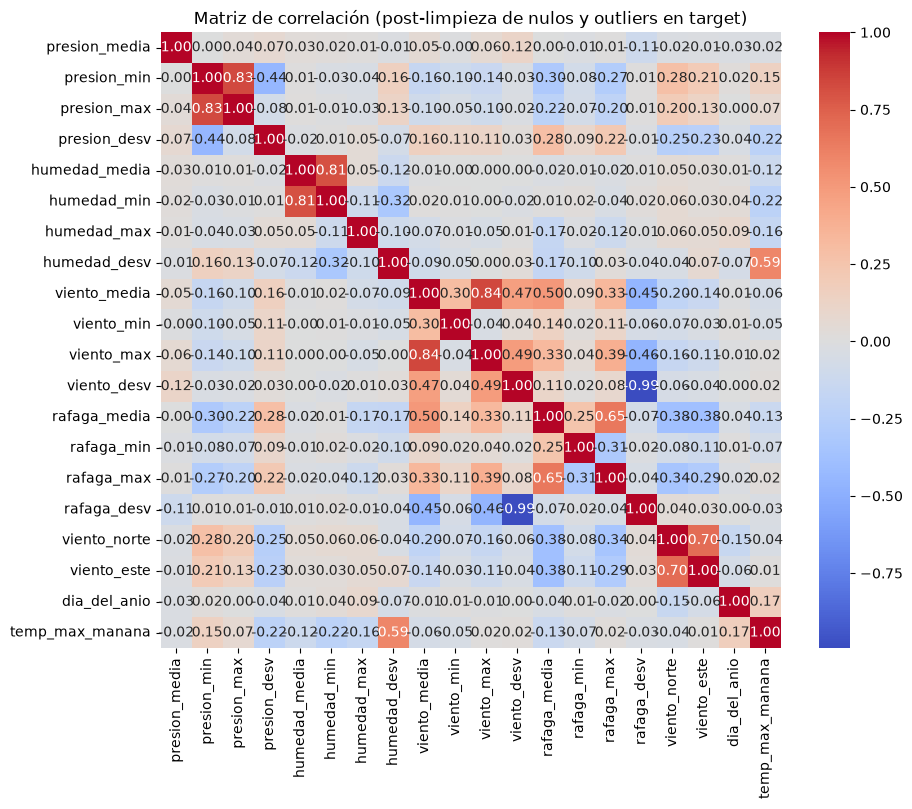

Variables numéricas restantes:
['presion_media', 'presion_desv', 'humedad_media', 'humedad_desv', 'viento_media', 'viento_desv', 'rafaga_media', 'rafaga_desv', 'viento_norte', 'viento_este', 'dia_del_anio', 'temp_max_manana']


In [157]:

df = df.dropna(subset=["temp_max_manana"])

def limites_std(serie, n=2.5):
    media = serie.mean()
    std = serie.std()
    return media - n * std, media + n * std

for col in df.select_dtypes(include=np.number).columns.drop("temp_max_manana"):
    lim_inf, lim_sup = limites_std(df[col], n=2.5)
    n_outliers = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    print(f"{col}: {n_outliers} outliers fuera de [{lim_inf:.2f}, {lim_sup:.2f}]")

lim_inf_target, lim_sup_target = limites_std(df["temp_max_manana"], n=2.5)
print(f"\ntemp_max_manana - Límites IQR: [{lim_inf_target:.2f}, {lim_sup_target:.2f}]")

outliers_target = df[(df["temp_max_manana"] < lim_inf_target) | (df["temp_max_manana"] > lim_sup_target)]
print("Outliers en temp_max_manana:", len(outliers_target))

df = df[(df["temp_max_manana"] >= lim_inf_target) & (df["temp_max_manana"] <= lim_sup_target)]

plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación (post-limpieza de nulos y outliers en target)")
plt.show()

# Copiamos los datos antes de eliminar las columnas para poder usarlas en otros modelos
df_backup = df.copy()

cols_eliminar_relacion = [
    "presion_min", "presion_max",
    "humedad_min", "humedad_max",
    "viento_min", "viento_max",
    "rafaga_min", "rafaga_max",
]

df = df.drop(columns=cols_eliminar_relacion)

print("Variables numéricas restantes:")
print(df.select_dtypes(include=np.number).columns.tolist())


Luego de estos ajustes, vemos que las correlaciones varian un poco, y ya con esta comamos decisiones sobre algunas varialbes que puedan afectar nuestro modelo, como es el caso de la variable `viento_desv`

Variables numéricas finales:
['presion_media', 'presion_desv', 'humedad_media', 'humedad_desv', 'viento_media', 'rafaga_media', 'rafaga_desv', 'viento_norte', 'viento_este', 'dia_del_anio', 'temp_max_manana']


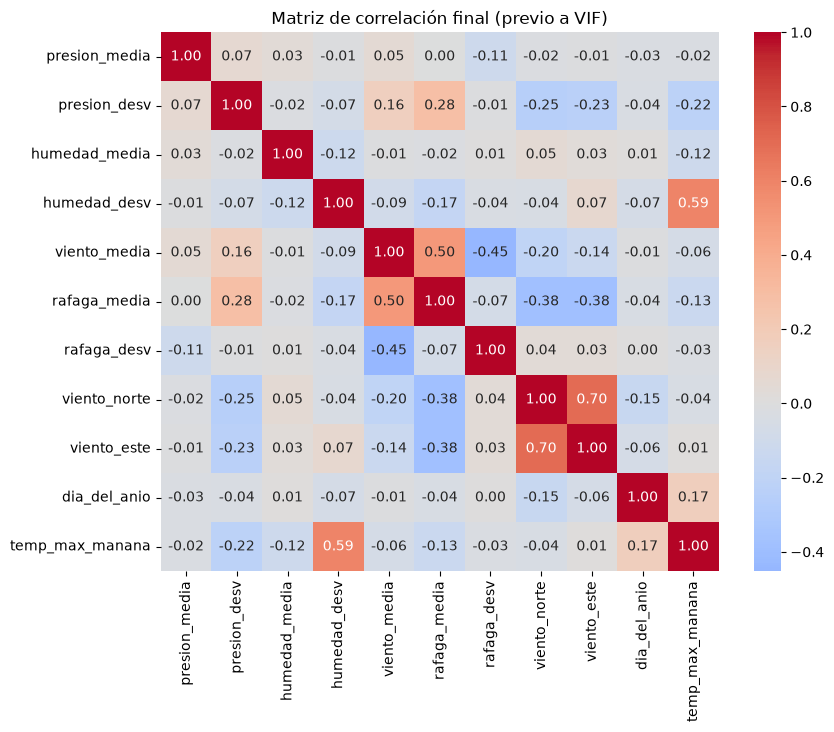

In [158]:

cols_eliminar = [
    "viento_desv",
]

df = df.drop(columns=cols_eliminar)

print("Variables numéricas finales:")
print(df.select_dtypes(include=np.number).columns.tolist())

plt.figure(figsize=(9, 7))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación final (previo a VIF)")
plt.show()

# Modelo 1
Ya con este analisis de nuestros datos y sus variables, podemos empezar a constriuir nuestro pippeline y modelo.

In [159]:
cols_eliminar = [
    "fecha", "anio", "direccion_viento", "sector_viento",
    "registros_del_dia",
    "presion_min", "presion_max", "humedad_min", "humedad_max",
    "viento_min", "viento_max", "viento_desv", "rafaga_max",
]

def eliminar_columnas(X):
    return X.drop(columns=cols_eliminar, errors="ignore")


# --- Normalización de categóricas ---
mapa_mes = {
    'january': 'enero', 'jan': 'enero', 'enero': 'enero',
    'february': 'febrero', 'feb': 'febrero', 'febrero': 'febrero',
    'march': 'marzo', 'mar': 'marzo', 'marzo': 'marzo',
    'april': 'abril', 'apr': 'abril', 'abril': 'abril',
    'may': 'mayo', 'mayo': 'mayo',
    'june': 'junio', 'jun': 'junio', 'junio': 'junio',
    'july': 'julio', 'jul': 'julio', 'julio': 'julio',
    'august': 'agosto', 'aug': 'agosto', 'agosto': 'agosto',
    'september': 'septiembre', 'sep': 'septiembre', 'sept': 'septiembre', 'septiembre': 'septiembre',
    'october': 'octubre', 'oct': 'octubre', 'octubre': 'octubre',
    'november': 'noviembre', 'nov': 'noviembre', 'noviembre': 'noviembre',
    'december': 'diciembre', 'dec': 'diciembre', 'diciembre': 'diciembre',
}

mapa_estacion = {
    'invierno': 'invierno', 'inverano': 'invierno', 'invernio': 'invierno', 'winter': 'invierno',
    'verano': 'verano', 'berano': 'verano', 'verno': 'verano', 'summer': 'verano',
    'primavera': 'primavera', 'primaveraa': 'primavera', 'primav': 'primavera', 'spring': 'primavera',
    'otono': 'otono', 'fall': 'otono', 'autumn': 'otono',
}

def limpiar_texto_base(serie):
    return (
        serie.astype(str).str.strip().str.lower()
             .apply(lambda x: unicodedata.normalize('NFKD', x)
                    .encode('ascii', 'ignore').decode('utf-8'))
    )

def normalizar_categoricas(X):
    X = X.copy()
    X["mes"] = limpiar_texto_base(X["mes"]).map(mapa_mes)
    X["estacion_anio"] = limpiar_texto_base(X["estacion_anio"]).map(mapa_estacion)
    return X


cols_categoricas = ["mes", "estacion_anio"]
cols_numericas = [
    "presion_media", "presion_desv",
    "humedad_media", "humedad_desv",
    "viento_media", "viento_norte", "viento_este",
    "rafaga_media", "rafaga_desv","dia_del_anio"
]

preprocesador = ColumnTransformer(transformers=[
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cols_categoricas),

    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler())
    ]), cols_numericas),
])

# --- Pipeline completo ---
modelo = Pipeline([
    ("drop_cols", FunctionTransformer(eliminar_columnas)),
    ("normalizar_cat", FunctionTransformer(normalizar_categoricas)),
    ("preprocesador", preprocesador),
    ("regresor", LinearRegression())
])

modelo

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('drop_cols', ...), ('normalizar_cat', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function eli...00289DA842020>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=None

In [160]:
target = "temp_max_manana"
X = df.drop(columns=[target])
y = df[target]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)

modelo.fit(X_train, y_train)
pred_val = modelo.predict(X_val)
print("Predicciones:", pred_val[:5])

rmse = np.sqrt(mean_squared_error(y_val, pred_val))
mae = mean_absolute_error(y_val, pred_val)
r2 = r2_score(y_val, pred_val)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2: {r2:.3f}")


from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predicciones sobre TRAIN (los mismos datos con los que se entrenó)
pred_train = modelo.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
mae_train = mean_absolute_error(y_train, pred_train)
r2_train = r2_score(y_train, pred_train)

# Predicciones sobre VALIDACIÓN (datos que el modelo no vio al entrenar)
pred_val = modelo.predict(X_val)
rmse_val = np.sqrt(mean_squared_error(y_val, pred_val))
mae_val = mean_absolute_error(y_val, pred_val)
r2_val = r2_score(y_val, pred_val)

tabla_fit = pd.DataFrame({
    "Conjunto": ["Train", "Validación"],
    "RMSE": [rmse_train, rmse_val],
    "MAE": [mae_train, mae_val],
    "R2": [r2_train, r2_val]
})
tabla_fit


Predicciones: [19.89900888 21.42060666 18.29029481  5.8681653  17.75595618]
RMSE: 6.48
MAE: 5.28
R2: 0.434


,Conjunto,RMSE,MAE,R2
0,Train,6.491544,5.14208,0.472872
1,Validación,6.480805,5.27767,0.434000


Análisis del ajuste del modelo (train vs. validación): el modelo presenta métricas muy similares entre el conjunto de entrenamiento (RMSE=6.49, MAE=5.14, R²=0.473) y el de validación (RMSE=6.48, MAE=5.28, R²=0.434), lo que descarta sobreajuste (overfitting), ya que el modelo no memoriza particularidades del entrenamiento sino que generaliza de forma consistente a datos nuevos. Sin embargo, ambos errores son relativamente altos y el R² se mantiene por debajo de 0.5 en los dos conjuntos, lo que indica subajuste (underfitting): el modelo es demasiado simple para capturar la relación entre las variables predictoras y la temperatura máxima del día siguiente. Esto es consistente con el análisis de correlación previo, donde ninguna variable individual mostró una relación fuerte con el objetivo (la más alta fue humedad_desv con 0.58); dado que la regresión lineal solo puede modelar relaciones lineales aditivas, su capacidad predictiva está limitada por la naturaleza y fuerza de las relaciones presentes en los datos, más que por un error de implementación o ajuste excesivo del modelo.

# Modelo 2

Para este segundo modelo hemos decido dejar las variables de minimos o maximos que mas relacion con la variable objetivo tengan, lineal o inversamente lineal.

In [161]:
cols_eliminar_2 = [
    "fecha", "anio", "direccion_viento", "sector_viento",
    "registros_del_dia", "presion_max", "humedad_max",
    "viento_min", "rafaga_max",
]

def eliminar_columnas_2(X):
    return X.drop(columns=cols_eliminar_2, errors="ignore")


cols_categoricas_2 = ["mes", "estacion_anio"]
cols_numericas_2 = [
    "presion_media", "presion_desv",
    "humedad_media", "humedad_desv",
    "viento_media", "viento_norte", "viento_este",
    "rafaga_media", "rafaga_desv","dia_del_anio", "presion_min", "humedad_min", "viento_max", "viento_desv", "rafaga_min"
]

preprocesador_2 = ColumnTransformer(transformers=[
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cols_categoricas_2),

    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler())
    ]), cols_numericas_2),
])

# --- Pipeline completo ---
modelo2 = Pipeline([
    ("drop_cols", FunctionTransformer(eliminar_columnas_2)),
    ("normalizar_cat", FunctionTransformer(normalizar_categoricas)),
    ("preprocesador", preprocesador_2),
    ("regresor", LinearRegression())
])

modelo2

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('drop_cols', ...), ('normalizar_cat', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function eli...00289DD498E00>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=None

In [162]:
df2 = df_backup.copy()
df2.head()

,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,...,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,dia_del_anio,estacion_anio,mes,temp_max_manana
0,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,0.05,...,1.3783,0.25,2.255577,0.8488,-0.3618,-0.0223,1.0,invierno,January,-2.12
1,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,0.22,...,2.2274,0.63,6.130000,1.2544,0.4267,0.3689,2.0,invierno,JULY,-0.82
2,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,0.12,...,2.0651,0.38,4.880000,0.9330,-0.6993,-0.5268,3.0,invierno,January,-0.63
3,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,0.54,...,3.5649,1.38,4.430375,1.1835,-1.1268,-1.0413,4.0,invierno,JANUARY,-1.44
6,993.5064,991.50,998.41,1.8001,85.659700,80.800000,93.4,3.1011,0.7225,0.08,...,1.4833,NaN,2.330141,0.5552,-0.5664,0.1691,7.0,invierno,January,-4.06


In [163]:
target = "temp_max_manana"


X2 = df2.drop(columns=[target])
y2 = df2[target]

X_train_2, X_val_2, y_train_2, y_val_2 = train_test_split(X2, y2, test_size=0.25, random_state=42)

modelo2.fit(X_train_2, y_train_2)
pred_val = modelo2.predict(X_val_2)
print("Predicciones:", pred_val[:5])

rmse = np.sqrt(mean_squared_error(y_val_2, pred_val))
mae = mean_absolute_error(y_val_2, pred_val)
r2 = r2_score(y_val_2, pred_val)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2: {r2:.3f}")

# Predicciones sobre TRAIN (los mismos datos con los que se entrenó)
pred_train_2 = modelo2.predict(X_train_2)
rmse_train_2 = np.sqrt(mean_squared_error(y_train_2, pred_train_2))
mae_train_2 = mean_absolute_error(y_train_2, pred_train_2)
r2_train_2 = r2_score(y_train_2, pred_train_2)

# Predicciones sobre VALIDACIÓN (datos que el modelo no vio al entrenar)
pred_val_2 = modelo2.predict(X_val_2)
rmse_val_2 = np.sqrt(mean_squared_error(y_val_2, pred_val_2))
mae_val_2 = mean_absolute_error(y_val_2, pred_val_2)
r2_val_2 = r2_score(y_val_2, pred_val_2)

tabla_fit_2 = pd.DataFrame({
    "Conjunto": ["Train", "Validación"],
    "RMSE": [rmse_train_2, rmse_val_2],
    "MAE": [mae_train_2, mae_val_2],
    "R2": [r2_train_2, r2_val_2]
})
tabla_fit_2


Predicciones: [20.15481724 21.3088494  18.43008205  6.16043862 18.01703469]
RMSE: 6.49
MAE: 5.28
R2: 0.432


,Conjunto,RMSE,MAE,R2
0,Train,6.473540,5.132598,0.475792
1,Validación,6.490054,5.281258,0.432383


# Analisis de resultados

Esta es la tabla comparativa de los 2 modelos, senota que e

In [ ]:
tabla_comparativa = pd.concat([
    tabla_fit.assign(Modelo="Modelo 1 - Reducido (sin min/max)"),
    tabla_fit_2.assign(Modelo="Modelo 2 - Completo (con min/max)")
])[["Modelo", "Conjunto", "RMSE", "MAE", "R2"]].reset_index(drop=True)

tabla_comparativa

In [164]:
feature_names = modelo.named_steps["preprocesador"].get_feature_names_out()
feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in feature_names
]

coef_df = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": modelo.named_steps["regresor"].coef_
})

print("Intercepto:", modelo.named_steps["regresor"].intercept_)
coef_df

Intercepto: 13.69282612041111


,Variable,Coeficiente
0,mes_abril,-0.003702
1,mes_agosto,2.318544
2,mes_diciembre,-3.006329
3,mes_enero,-1.184342
4,mes_febrero,-2.039511
5,mes_julio,3.394434
6,mes_junio,2.740635
7,mes_marzo,-1.967869
8,mes_mayo,1.761855
9,mes_noviembre,-1.959365


# Predicciones sobre test

Predicciones con el modelo elegido (1)

In [ ]:
predicciones_test = modelo.predict(df_test)

print("Predicciones generadas:", len(predicciones_test))
print("Rango:", predicciones_test.min(), "a", predicciones_test.max())
print("Nulos en predicciones:", np.isnan(predicciones_test).sum())

print("Rango real en train:", df["temp_max_manana"].min(), "a", df["temp_max_manana"].max())

df_salida = df_test.copy()
df_salida["temp_max_manana"] = predicciones_test

df_salida.head()

df_salida.to_csv("Datos Test Lab1.csv", index=False)

print("Archivo exportado correctamente.")
print(df_salida[["temp_max_manana"]].describe())

Predicciones generadas: 364
Rango: -5.322161999696336 a 30.127886648452844
Nulos en predicciones: 0
Rango real en train: -9.0 a 36.4


## Análisis de resultados

**1. ¿Cuál fue el valor de los diferentes coeficientes obtenidos en el mejor modelo?**

El modelo seleccionado (Modelo 1, reducido sin min/max) presenta el siguiente perfil de coeficientes (variables ya escaladas con `RobustScaler`, salvo las categóricas codificadas con one-hot):

La variable con mayor peso es, por lejos, **`humedad_desv`** (coeficiente = 7.16), seguida de **`dia_del_anio`** (3.50) y **`mes_julio`** (3.39). En el extremo negativo, **`mes_diciembre`** (-3.01) y **`presion_desv`** (-1.80) tienen el mayor efecto reductor sobre la temperatura predicha.

Variables como `presion_media`, `viento_media`, `rafaga_media` y `rafaga_desv` tienen coeficientes cercanos a cero (entre -0.02 y 0.06), indicando aporte marginal una vez controlado por las demás variables.

Los meses siguen un patrón estacional coherente: coeficientes positivos en meses cálidos del hemisferio norte (`julio` = 3.39, `junio` = 2.74, `agosto` = 2.32, `mayo` = 1.76) y negativos en meses fríos (`diciembre` = -3.01, `febrero` = -2.04, `marzo` = -1.97, `noviembre` = -1.96), lo cual es consistente con el ciclo estacional esperado para Jena, Alemania.

---

**2. ¿Cuál modelo ofrece el mejor rendimiento sobre el conjunto de validación? Interpretación**

| Modelo                            | RMSE (val) | MAE (val) | R² (val) |
| --------------------------------- | ---------: | --------: | -------: |
| Modelo 1 - Reducido (sin min/max) |       6.48 |      5.28 |    0.434 |
| Modelo 2 - Completo (con min/max) |       6.49 |      5.28 |    0.432 |

El Modelo 1 ofrece un rendimiento marginalmente mejor, aunque la diferencia (0.01 en RMSE, 0.002 en R²) no es relevante en la práctica. Esto confirma que las variables `_min`/`_max` eran redundantes frente a `_media`/`_desv`: agregarlas no mejora la capacidad predictiva del modelo, solo aumenta su complejidad y el riesgo de coeficientes inestables por colinealidad.

Se elige el Modelo 1 por **parsimonia e interpretabilidad**, sin sacrificar desempeño.

En términos absolutos, un **RMSE ≈ 6.48 °C** y un **MAE ≈ 5.28 °C** indican que, en promedio, el modelo se equivoca en más de 5 °C al predecir la temperatura máxima del día siguiente. El RMSE, al ser más sensible a errores grandes, sugiere además la presencia de algunos errores puntuales considerables.

Un **R² ≈ 0.43** significa que el modelo explica menos de la mitad de la variabilidad del objetivo. Para el caso de negocio de AlpesPlanck (alertas de incendios forestales, fenómenos de El Niño/La Niña), este margen de error es significativo: el modelo puede ser útil como indicador de tendencia general (por ejemplo, anticipar que se acerca un periodo de temperaturas altas), pero no es lo suficientemente preciso como para sustentar decisiones operativas que requieran exactitud fina en grados.

---

**3. ¿Cuáles variables fueron seleccionadas? Interpretación de cara al problema**

Las variables seleccionadas fueron:

* `mes`
* `estacion_anio` (categóricas)
* `presion_media`
* `presion_desv`
* `humedad_media`
* `humedad_desv`
* `viento_media`
* `viento_norte`
* `viento_este`
* `rafaga_media`
* `rafaga_desv`
* `dia_del_anio`

La variable más influyente es **`humedad_desv`** (variabilidad de la humedad relativa durante el día), con un coeficiente muy superior al resto. Esto indica que **no es el nivel promedio de humedad, sino qué tanto varió durante el día**, lo que más se asocia con temperaturas máximas altas al día siguiente.

Le siguen en importancia las variables de estacionalidad (`dia_del_anio`, `mes`), lo cual es esperable, pero también confirma que el ciclo anual captura buena parte de la señal disponible en los datos.

Para AlpesPlanck, esto sugiere una decisión concreta: monitorear la **dispersión intradía de humedad** (no solo su promedio, que es lo que suele reportarse en resúmenes meteorológicos estándar) como posible indicador de alerta temprana.

Si días con alta variabilidad de humedad anteceden temperaturas máximas elevadas, esto podría incorporarse como una señal adicional en los sistemas de monitoreo de riesgo de incendios forestales, más allá de las métricas de temperatura y humedad promedio que normalmente se usan.

> **Nota:** esta interpretación debe entenderse como una asociación predictiva y no necesariamente como una relación causal. Un coeficiente alto indica que la variable aporta información al modelo, pero no demuestra por sí mismo que los cambios en dicha variable sean la causa de los cambios en la temperatura.

---

**4. ¿Cómo representar la regresión lineal de forma matemática?**

La regresión lineal puede representarse matemáticamente como:

$$
\hat{y} = \beta_0 + \beta_1x_1 + \beta_2x_2 + \dots + \beta_nx_n
$$

Donde:

* $\hat{y}$ es la temperatura máxima predicha del día siguiente (`temp_max_manana`).
* $\beta_0$ es el intercepto.
* $\beta_i$ es el coeficiente asociado a la variable predictora $x_i$.
* $x_i$ representa cada variable predictora ya transformada: escalada para las variables numéricas y codificada mediante one-hot para las variables categóricas.

El método utilizado por `LinearRegression` de `scikit-learn` es **mínimos cuadrados ordinarios (OLS)**. Este método busca los valores de $\beta$ que minimizan la suma de los errores al cuadrado entre los valores reales y los predichos:

$$
\min_{\beta} \sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

El problema tiene una solución mediante álgebra matricial:

$$
\hat{\beta} = (X^TX)^{-1}X^Ty
$$

En la práctica, `scikit-learn` utiliza métodos numéricamente más estables, como la **descomposición SVD**, para resolver el problema de mínimos cuadrados sin necesidad de realizar directamente la inversión de la matriz $X^TX$.

---

**5. ¿Qué tipos de sesgo podrían afectar los resultados?**

* **Sesgo de calidad de datos (data quality bias):** durante la exploración se identificaron problemas como categorías inválidas o inconsistentes en `estacion_anio` (`'East'`, `'Estacion_Desconocida'`, `'VERANO_INVIERNO'`, mezcla de idiomas en `mes`) y un valor de temperatura físicamente imposible en el objetivo (63 °C). Si estos errores no se detectan y corrigen antes de entrenar, el modelo aprende patrones distorsionados por ruido en los datos, sesgando tanto los coeficientes como las predicciones.

* **Sesgo de variable omitida (omitted variable bias):** el R² ≈ 0.43 indica que una parte considerable de la variabilidad de la temperatura no es explicada por las variables disponibles. Esto sugiere la ausencia de variables relevantes, como radiación solar, cobertura de nubes o temperatura de días anteriores, que pueden influir en la temperatura máxima del día siguiente.

  Cuando estas variables omitidas están correlacionadas con las variables sí incluidas en el modelo, los coeficientes estimados pueden estar capturando parcialmente su efecto de forma indirecta y sesgada, en vez de reflejar el efecto causal real de cada variable meteorológica medida.


# Declaracion de uso de IA

**Herramienta utilizada:** Claude (Anthropic) — usada para: ayuda conceptual sobre 
colinealidad/VIF, generación inicial de código para pipelines de sklearn, depuración 
de errores (ValueError de columnas, NaN en target), y estructuración del análisis de resultados.

**Prompts principales:** EN los analisis de resultados, se pasaron las metricas y cuales fueron los procesos de pensamiento para la seleccions y creaciones de los modelos, y se pidio ayuda para identificar las cosas y los estructuro para responder las preguntas

**Decisiones propias:** La seleccion del modelo y de las variables que se iban a trabajar, la manera de imputar los datos y manejar todos los temas de completitud, unicidad y consistencia.
